In [ ]:
# Para tratamiento de datos
import polars as pl
import math
# Para visualizaciones
import seaborn as sns 
import matplotlib.pyplot as plt
# Para gestión de fechas
from datetime import datetime
# Para conectar a la base de datos
import psycopg2
# Cargar variables de entorno
import os
import sys
from dotenv import load_dotenv
# Configuracion de Polars para mostrar todas las columnas y hasta 25 filas
pl.Config.set_tbl_rows(25)  # Asegura que se muestren hasta 1000 filas
pl.Config.set_tbl_width_chars(500)  # Aumenta el ancho para evitar cortes
# Configuracion para importar src
current_working_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_working_dir, '..', '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
# importamos funciones de soporte
from src import funciones_load as fl
from src import funciones_eda as feda

In [2]:
conexion = os.getenv("conexion_bbdd")
madrid_19 = feda.obtener_datos_madrid(conexion, 2019, 2019, "Madrid")

Conexión establecida y consulta de prueba exitosa.


In [3]:
df_mensual, estaciones, contaminantes = feda.preproceso_datos(madrid_19)

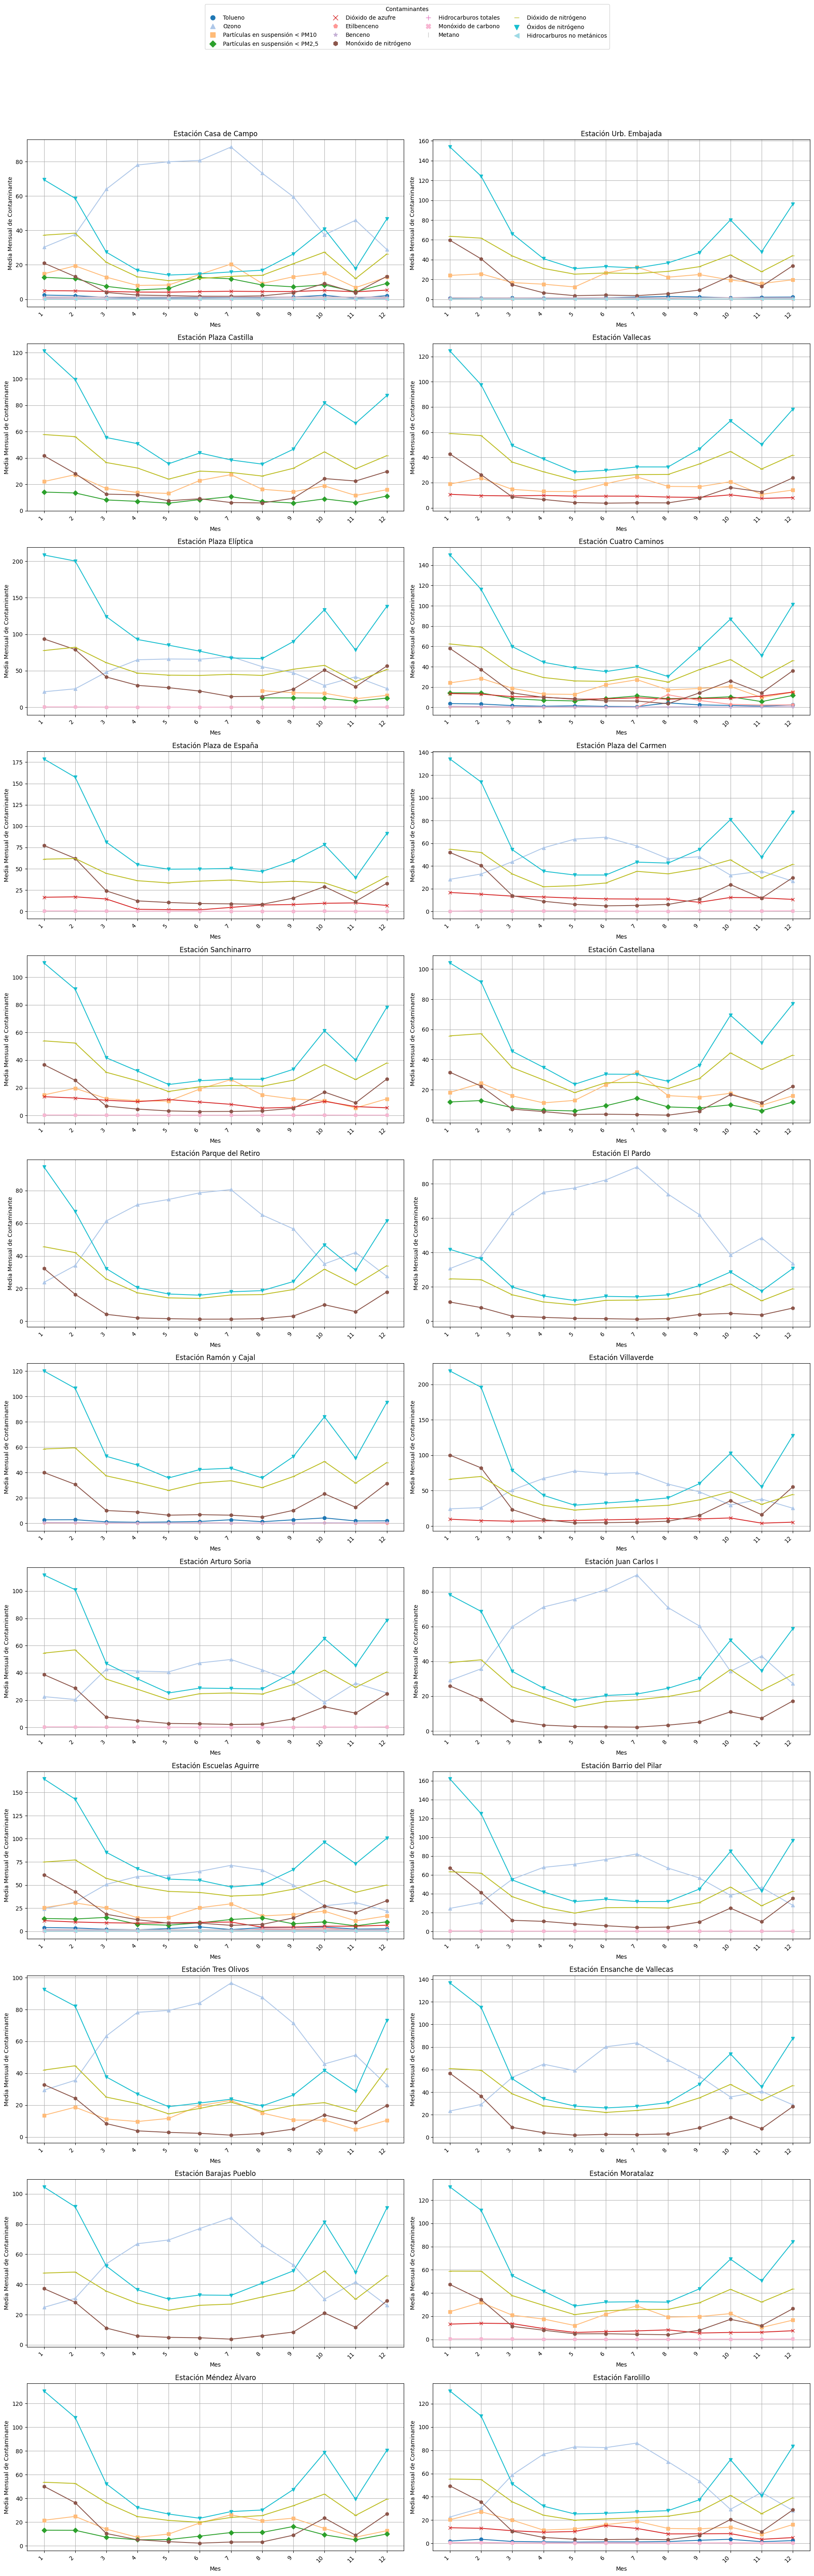

In [4]:
feda.graficos_estaciones(df_mensual, estaciones, contaminantes)

Analizamos los contaminantes que se miden en más estaciones, ya que son los que permiten mejor comparación entre ellas.

In [5]:
contaminantes_por_estacion = (
    madrid_19.group_by("contaminante")
    .agg(pl.col("estacion").n_unique().alias("num_estaciones"))
    .sort("num_estaciones", descending=True)  # Opcional, para ordenar de mayor a menor
)
contaminantes_por_estacion

contaminante,num_estaciones
str,u32
"""Dióxido de nitrógeno""",24
"""Monóxido de nitrógeno""",24
"""Óxidos de nitrógeno""",24
"""Ozono""",14
"""Partículas en suspensión < PM1…",13
"""Monóxido de carbono""",10
"""Dióxido de azufre""",10
"""Partículas en suspensión < PM2…",7
"""Etilbenceno""",6


Los **Óxidos de nitrógeno** siguen un patrón muy similar en todas las estaciones, con un descenso marcado de enero a marzo, una cierta estabilidad ente marzo y agosto y otra subida en octubre, sin embargo este año se produce una caída en noviembre para luego volver a subir en diciembre, pero sin llegar a superar los valores de enero. Podría sugerir un final de otoño más cálido. Además, salvo en las estaciones donde se mide ozono, sigue siendo el contaminante que alcanza mayores valores.    
Tanto el **Dióxido de nitrógeno** como el **Monóxido de nitrógeno** siguen un patrón similar al de los óxidos de nitrógeno, pero sin alcanzar valores tan altos, aunque el dióxido de nitrógeno sigue siendo el segundo contaminante más alto, salvo las mismas excepciones que el caso anterior, en las que el ozono tiene una tendencia opuesta.   
El **Ozono**, se mide en 14 de las 24 estaciones y, en las estaciones que lo miden tiene un patrón opuesto al de todos los óxidos de nitrógeno: mínimos en enero y diciembre y máximos en torno a julio - agosto.  Además este año también se aprecia el patrón opuesto en octubre - noviembre, mientras que los óxidos de nitrógeno suben en octubre, caen en noviembre y vuelven a subir en diciembre, el ozono cae en octubre, sube en noviembre y vuelve a caer en diciembre.
El siguiente que aparece en más estaciones es **Partículas en suspensión < PM10** que en este año presenta picos en febrero y julio, aunque el de julio es mayor.   
El **monóxido de carbono** se mide en 10 estaciones aunque parece tener un valor muy cercano a 0 en todas las estaciones todo el año.  
El **dióxido de azufre** también se mide en 10 estaciones y aunque se mantiene relativamente en niveles bajos, este año parece presentar una tendencia descendente a lo largo del año.  
Como dato a destacar, este año, desde agosto, se miden dos contaminantes nuevos en la estación de Plaza Elíptica: Partículas en suspensión < PM10 y Partículas en suspensión < PM2,5.
